In [35]:
import pandas as pd

df = pd.read_csv('D:\MOHIT\BITSOM\Assignment4(A+B)\ml-assessment-mohit-koli\data\q3_retail_promotions.csv')
df.head

<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10336\407787699.py:3: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('D:\MOHIT\BITSOM\Assignment4(A+B)\ml-assessment-mohit-koli\data\q3_retail_promotions.csv')


<bound method NDFrame.head of      transaction_date  store_id  ... competition_density items_sold
0          2022-01-01        28  ...                   5        224
1          2022-01-01         5  ...                   1        348
2          2022-01-02        13  ...                   6        249
3          2022-01-02        17  ...                   7        259
4          2022-01-03        50  ...                   3        277
...               ...       ...  ...                 ...        ...
1195       2024-12-28        39  ...                   3        384
1196       2024-12-28        44  ...                   9        371
1197       2024-12-29        47  ...                   7        367
1198       2024-12-31        25  ...                   6        321
1199       2024-12-31        37  ...                   6        296

[1200 rows x 9 columns]>

In [36]:
#1. Date Feature Engineering

#convert date column to datetime

df['transaction_date'] = pd.to_datetime(df['transaction_date']) 

#features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek # 0=monday, 6=sunday

# month end
df['month_end'] = (df['transaction_date'].dt.day > 25).astype(int)
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [37]:
#2.Temporal Train-Test Split

#sort by date

df = df.sort_values('transaction_date')

#split (80% train, 20% test)

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

Random split is not suitale for time-based data because it mixes past and future data.
In practical scenarios, we only predict future using past data, so we must preserve time order.

In [38]:
#3. Preprocessing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


#define features 
target = 'items_sold'


from sklearn.model_selection import train_test_split

X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

#define column types
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

#preprocessing for numerical data
preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])



In [39]:
#4. model training and evaluation

#A. Linear Regression

from sklearn import pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#pipeline

lr_pipeline = Pipeline([('preprocessing', preprocessor),
                        ('model', LinearRegression())])

#Train
lr_pipeline.fit(X_train, y_train)

#Predict
y_pred_lr = lr_pipeline.predict(X_test)

#metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression RMSE:", rmse_lr)
print(f"Linear Regression MAE:", mae_lr)



#B. Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest RMSE:", rmse_rf)
print(f"Random Forest MAE:", mae_rf)



Linear Regression RMSE: 27.114314576361732
Linear Regression MAE: 21.048595843888187
Random Forest RMSE: 30.846505184272225
Random Forest MAE: 24.260624999999997


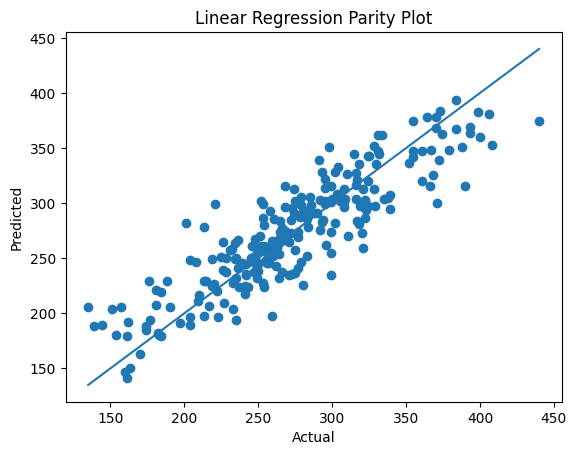

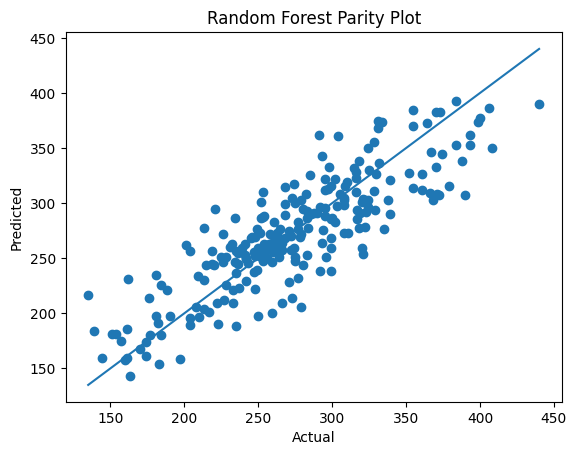

In [40]:
#Parity plot

import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred,)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(title)
    plt.show()

    #plots
parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

In [41]:
# Feature importance for Random Forest

# Get feature names after encoding
encoded_features = rf_pipeline.named_steps['preprocessing'].get_feature_names_out()

# Importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'feature': encoded_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 5
print(feature_importance_df.head(5))

                     feature  importance
2           num__is_festival    0.173353
18     cat__store_size_small    0.166304
15  cat__location_type_urban    0.107819
6           num__day_of_week    0.083087
1            num__is_weekend    0.064417
